# STAT 207 Group Lab Assignment 12 - [10 total points]

## Classifiers

<hr>

## <u>Lab Grading</u>:

Should we grade your submission?  If not, write the netID of the submission to be graded.  (Note: We will only grade one assignment per group, and we'll pick the first one that says we should grade that submission.  We will assign the same grade to all team members.)

*For example*, you might respond: **grade this submission** or **my submission is under netID jdeeke**

mdm16

If you said **my submission is under netID** above, we will not read any more of your lab submission.

If you said **grade this submission** above, who worked with you on this submission?  Write both their **names** and **netIDs**.  Also, discuss and record if you attended a University of Illinois basketball game in the last year.

## <u>Purpose</u>:
You should work in groups of 2-3 on this report (not working in groups without permission will result in a point deduction). The purpose of this group lab assignment is to create and evaluate a classifier, followed by tuning our classifier based on its future use.
<hr>

## <u>Assignment Instructions</u>:

### Group Roles

Suggested and specified roles are provided below: 

#### Groups of 2

* **Driver**: This student will type the report.  While typing the report, you may be the one who is selecting the functions to apply to the data.
* **Navigator**: This student will guide the process of answering the question.  Specific ways to help may include: outlining the general steps needed to solve a question (providing the overview), locating examples within the course notes, and reviewing each line of code as it is typed.

#### Groups of 3

* **Driver**: This student will type the report.  They may also be the one to select the functions to apply to the data.
* **Navigator**: This student will guide the process of answering the question.  They may select the general approach to answering the question and/or a few steps to be completed along the way. 
* **Communicator**: This student will review the report (as it is typed) to ensure that it is clear and concise.  This student may also locate relevant examples within the course notes that may help complete the assignment.

<hr>

### Imports

In [2]:
#Run this
import pandas as pd                    # imports pandas and calls the imported version 'pd'
import matplotlib.pyplot as plt        # imports the package and calls it 'plt'
import seaborn as sns                  # imports the seaborn package with the imported name 'sns'
sns.set()  
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
def plot_roc(fpr, tpr, auc, lw = 2):
    plt.plot(fpr, tpr, color = 'darkorange', lw = lw, label = 'ROC curve (area = '+str(round(auc, 3))+')')
    plt.plot([0,1], [0,1], color = 'navy', lw = lw, linestyle = '--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc = 'lower right')
    plt.show()
def fpr_tpr_thresh(y, pred_prob, thresh):
    yhat = 1 * (pred_prob >= thresh)
    tn, fp, fn, tp = confusion_matrix(y_true = y, y_pred = yhat).ravel()
    tpr = tp / (fn + tp)
    fpr = fp / (fp + tn)
    return (pd.DataFrame({'threshold':[thresh],
                          'fpr':[fpr],
                          'tpr':[tpr]}))

## Case Study: Understanding NBA Longevity

We will look at data collected on rookies in the NBA from 1980-2016 to determine if the rookies are successful and still playing in the NBA after 5 years.  The available variables include the following **per game** statistics:

- **GP**: number of games played
- **MIN**: number of minutes played per game
- **PTS**: number of points scored per game
- **FGM**: number of field goals made per game
- **FGA**: number of field goals attempted per game
- **FG%**: percentage of field goals made per game
- **3P Made**: number of 3-point field goals made per game
- **3PA**: number of 3-point field goals attempted per game
- **3P%**: percentage of 3-point field goals made per game
- **FTM**: number of free throws made per game
- **FTA**: number of free throws attempted per game
- **FT%**: percentage of free throws made per game
- **OREB**: number of offensive rebounds per game
- **DREB**: number of defensive rebounds per game
- **REB**: total number of rebounds per game
- **AST**: number of assists per game
- **STL**: number of steals per game
- **BLK**: number of blocks per game
- **TOV**: number of turnovers per game
- **TARGET_5Yrs**: whether the player is still playing in the NBA after 5 years (1 = playing, 0 = not playing)

The code cell below will read in the data for you.  Be sure to run the cell. 

In [3]:
df = pd.read_csv('nba_rookie.csv')

### 1. [5 points] Fit a Classifier

Recall that in Lab 11, we built a logistic regression model to predict whether a player will last for 5 years or more in the NBA from four variables in the data (of your choosing).  We will continue exploring this data in Lab 12.

**a)** Fit a model predicting whether the player lasts 5 years or more in the NBA from four of the other variables in the data.  You may pick the combination of four variables to use as predictors.  You may choose to use the same variables from Lab 11, or you may explore a different combination of variables.

In [4]:
from sklearn.linear_model import LogisticRegression

X = df[['GP', 'MIN', 'PTS', 'REB']]
y = df['TARGET_5Yrs']

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X, y)

/Users/matthewmandhyan/Desktop/Stat207/mdm16/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/matthewmandhyan/Desktop/Stat207/mdm16/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/matthewmandhyan/Desktop/Stat207/mdm16/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


LogisticRegression(max_iter=1000)

**b)** Generate the predictive probabilities from your model, and save them as a new column in the existing data.

In [5]:
df['pred_prob'] = log_reg.predict_proba(X)[:, 1]

/Users/matthewmandhyan/Desktop/Stat207/mdm16/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matthewmandhyan/Desktop/Stat207/mdm16/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matthewmandhyan/Desktop/Stat207/mdm16/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


**c)** Generate predictions for a classifier with a predictive probability threshold of 0.5.  Save these predictions as a new column in your existing data.

In [6]:
df['pred_5yrs'] = 1 * (df['pred_prob'] >= 0.5)

df.head()


,Name,GP,MIN,PTS,FGM,FGA,FG_Perc,3P Made,3PA,3P_Perc,...,OREB,DREB,REB,AST,STL,BLK,TOV,TARGET_5Yrs,pred_prob,pred_5yrs
0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,...,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0,0.377001,0
1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,...,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0,0.283995,0
2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,...,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0,0.722876,1
3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,22.6,...,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1,0.624807,1
4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,0.0,...,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1,0.511825,1


**d)** Generate the confusion matrix for the classifier from part **c**.

In [7]:
confusion_matrix(y_true=df['TARGET_5Yrs'], y_pred=df['pred_5yrs'])


array([[261, 224],
       [149, 675]])

**e)** Calculate (and report) the accuracy rate, sensitivity, and specificity for this classifier.  You may do this completely using code, you may use Python as a calculator, or you may use your own calculator.  Be sure to show your work below regardless of your calculation method.

In [9]:
tn, fp, fn, tp = confusion_matrix(
    y_true=df['TARGET_5Yrs'],
    y_pred=df['pred_5yrs']
).ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
accuracy, specificity, sensitivity

(np.float64(0.7150496562261268),
 np.float64(0.5381443298969072),
 np.float64(0.8191747572815534))

### 2. [5 points] Selecting a Better Threshold

We used the "default" predictive probability threshold of 0.5 in Question 1 above.  We should question if this is an ideal threshold and will therefore aim to select our threshold more systematically.

**a)** Suppose that we are part of the coaching staff for an NBA team, and we would like to recruit young players from other teams who we anticipate will still be playing after 5 years in the league.  We don't want to waste our time recruiting young players who will not still be playing in the NBA at the end of their contract.

What type of error would be worse for a classifier?  Therefore, what type of error should we reduce?  And would you anticipate that the predictive probability threshold would increase or decrease?

the type of error that would be worse for our classifier is a False Postive (ie prediciting a player to last more than 5 years but they do no actually last the 5 years.). We should try adn reduce the False Positive error rate. To reduce false positives, we would increase the predictive probability threshold, making the classifier more selective before predicting that a player will last 5+ years.

**b)** Generate the ROC curve for the model from Question 1.

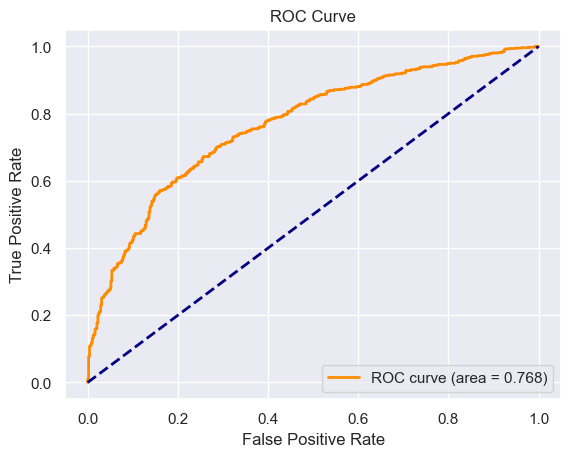

In [10]:
fpr, tpr, thresholds = roc_curve(
    y_true=df['TARGET_5Yrs'],
    y_score=df['pred_prob']
)

auc = roc_auc_score(
    y_true=df['TARGET_5Yrs'],
    y_score=df['pred_prob']
)

plot_roc(fpr, tpr, auc)


**c)** Select and identify the value for an "ideal" threshold using your ROC curve from **part b** and the errors to be minimized from **part a**.

In [11]:
roc_table = pd.DataFrame({
    'threshold': thresholds,
    'fpr': fpr,
    'tpr': tpr
})

roc_table = roc_table[np.isfinite(roc_table['threshold'])]

ideal_threshold_table = roc_table[roc_table['fpr'] <= 0.20].sort_values(
    by='tpr',
    ascending=False
).head(1)

ideal_threshold = ideal_threshold_table['threshold'].iloc[0]

ideal_threshold_table


,threshold,fpr,tpr
160,0.690476,0.197938,0.609223


**d)** Report the strength of the model when used as a classifier.  (*Hint*: this can be found from the ROC curve above).  If time, compare your model to another lab group and indicate which model performs better.

In [12]:
print("AUC:", auc)

AUC: 0.7682927134420978


This is a moderately strong classifier, with a moderate ability to distinguish players who last 5 or more years and players who do not. THe Auc value is .76829

### 3. AI Acknowledgement

Our course policy is that you should write all of your own interpretations and other narrative answers (phrases or sentences) yourself without the assistance of AI.  AI should not be used on Question 2a of this assignment.  

You may use AI to help guide your code, although you should write all of your own code yourself (not copy-paste from another source) and you should cite your use of AI.  I would encourage you to try to generate any necessary code yourself first using course resources and using AI as a debugging tool if/when you reach an error that you can't figure out or to help you perform any coding tasks that are more advanced than we've demonstrated during class (intended only for projects).  

Did you use AI on this assignment?  Did you use other resources outside of our course-provided resources on this assignment?

no

If you used AI or other resources, answer the following questions to cite your usage.

- Which AI and/or resources did you use?
- What prompts did you ask it?
- How did you integrate the responses into your assignment?  Specifically, which questions or parts are associated with this usage?

Note: answering these three questions are enough for our course but may not be enough for a different course or context.

N/a